<a href="https://colab.research.google.com/github/kmardamb/DATA-205-Spring-2026/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## 1. Project Introduction

For my final project for Data 201 I will be using the ABS (Alcohol Beverages Services) inventory and sales dataset from the data montgomery website. This dataset is comprised of 8 columns that help with predicting the prices of beverages using the beverages; size, sale price, inventory, and if the item is on sale. The topic is interesting because businesses can use predictive models to analyze future prices, sales, and potential customer behavior. A limitation of the dataset is that some of the variables are similar to their targer variable. Predictions may be made easier and help with the models performance.

My main goal with this project is to test between Random Forest, Gradient Boosting, and Single Decision Tree Regressor models.

Source: https://data.montgomerycountymd.gov/Community-Recreation/ABS-Store-Inventory-and-Sale-Items/ib5t-5ncy/about_data


## 2. Dataset & Preparation

The dataset has 7102 rows and 8 columns, the variables are stated in the table below. I removed and repetitive or missing data values, and categorical values were converted to numeric values to help with the predicitve modeling.

For the dataset I will be training and testing the model on a 80/20 split.

In [8]:
df = pd.read_csv("/ABS_Store_Inventory_and_Sale_Items_20260513.csv")
df.head()

,Code,Category,Description,Size,Total Inventory,Price,Sale Price,Sale End Date
0,89270,DOMESTIC VODKA,PLATINUM 10X VODKA - 750ML,750ML,0,$13.99,NaN,NaN
1,30180,DOMESTIC GIN,GILBEY'S GIN - 750ML,750ML,0,$8.99,NaN,NaN
2,381069,MISCELLANEOUS IMPORTED WINE,JINSOL ORIGINAL SOJU 20/375ML,375ML,0,$6.99,NaN,NaN
3,90937,TEQUILA,MAESTRO DOBEL DIAMANTE TEQUILA BARREL F1 750ML,750ML,0,$47.99,NaN,NaN
4,381445,KOSHER,UPSTATE VODKA 6/750ML,750ML,0,$34.99,NaN,NaN


| Variable | Description | Type |
|---|---|---|
| Price | Original item price before discounts | Quantitative |
| Sale Price | Final item price after discounts | Quantitative |
| Discount Amount | Dollar amount reduced from the original price | Quantitative |
| Discount Percent | Percentage discount applied to the item | Quantitative |
| Quantity | Number of items sold or available | Quantitative |
| Category | Product category or item classification | Categorical |

In [9]:
df.shape

(7102, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7102 entries, 0 to 7101
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Code             7102 non-null   object
 1   Category         7102 non-null   object
 2   Description      7102 non-null   object
 3   Size             7102 non-null   object
 4   Total Inventory  7102 non-null   int64 
 5   Price            7102 non-null   object
 6   Sale Price       232 non-null    object
 7   Sale End Date    232 non-null    object
dtypes: int64(1), object(7)
memory usage: 444.0+ KB


In [11]:
df.describe(include="all")

,Code,Category,Description,Size,Total Inventory,Price,Sale Price,Sale End Date
count,7102,7102,7102,7102,7102.000000,7102,232,232
unique,7102,105,7071,63,NaN,389,47,1
top,71039,AMERICAN RED,LAURENT PERRIER BRUT ROSE - 750ML,750ML,NaN,$12.99,$10.99,5/31/2026
freq,1,804,2,4585,NaN,302,27,232
mean,NaN,NaN,NaN,NaN,590.595607,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,3797.841915,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,234.000000,NaN,NaN,NaN


In [12]:
data = df.copy()


data["Price"] = data["Price"].replace('[\$,]', '', regex=True).astype(float)
data["Sale Price"] = data["Sale Price"].replace('[\$,]', '', regex=True).astype(float)


data["Sale Price"] = data["Sale Price"].fillna(data["Price"])


data["Sale End Date"] = pd.to_datetime(data["Sale End Date"], errors="coerce")


data["On Sale"] = np.where(data["Sale Price"] < data["Price"], 1, 0)
data["Discount Amount"] = data["Price"] - data["Sale Price"]
data["Discount Percent"] = (data["Discount Amount"] / data["Price"]) * 100

data["Category"] = data["Category"].fillna("Unknown")
data["Size"] = data["Size"].fillna("Unknown")
data["Description"] = data["Description"].fillna("Unknown")
data["Total Inventory"] = data["Total Inventory"].fillna(0)

data.head()

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_6614/951398137.py:4: SyntaxWarning: invalid escape sequence '\$'
  data["Price"] = data["Price"].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_6614/951398137.py:5: SyntaxWarning: invalid escape sequence '\$'
  data["Sale Price"] = data["Sale Price"].replace('[\$,]', '', regex=True).astype(float)


,Code,Category,Description,Size,Total Inventory,Price,Sale Price,Sale End Date,On Sale,Discount Amount,Discount Percent
0,89270,DOMESTIC VODKA,PLATINUM 10X VODKA - 750ML,750ML,0,13.99,13.99,NaT,0,0.0,0.0
1,30180,DOMESTIC GIN,GILBEY'S GIN - 750ML,750ML,0,8.99,8.99,NaT,0,0.0,0.0
2,381069,MISCELLANEOUS IMPORTED WINE,JINSOL ORIGINAL SOJU 20/375ML,375ML,0,6.99,6.99,NaT,0,0.0,0.0
3,90937,TEQUILA,MAESTRO DOBEL DIAMANTE TEQUILA BARREL F1 750ML,750ML,0,47.99,47.99,NaT,0,0.0,0.0
4,381445,KOSHER,UPSTATE VODKA 6/750ML,750ML,0,34.99,34.99,NaT,0,0.0,0.0


## 3. Exploratory Data Analysis

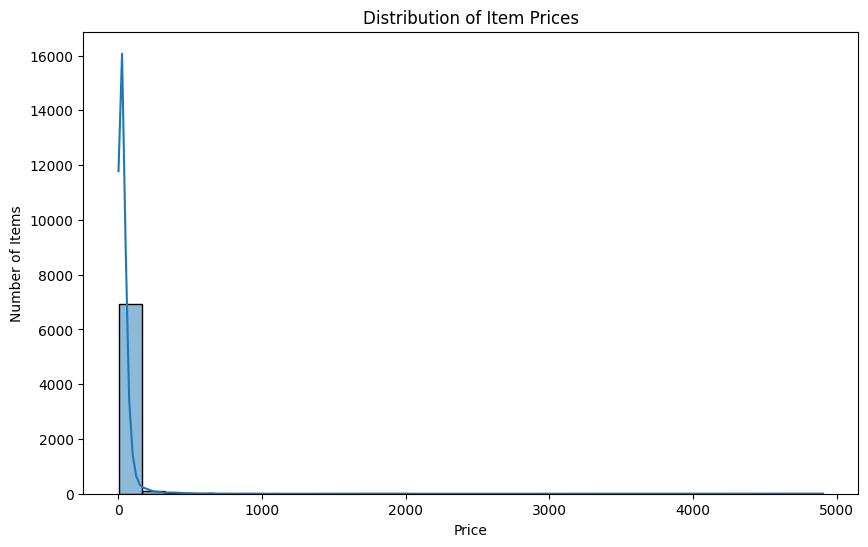

In [16]:
# Visualization 1: Price distribution
plt.figure(figsize=(10,6))
sns.histplot(data["Price"], bins=30, kde=True)
plt.title("Distribution of Item Prices")
plt.xlabel("Price")
plt.ylabel("Number of Items")
plt.show()

based on the histogram above we can see that the item prices are heavily right-skewed, a majority of the alcohol sold was rated at lower prices, while there were a few items priced higher.

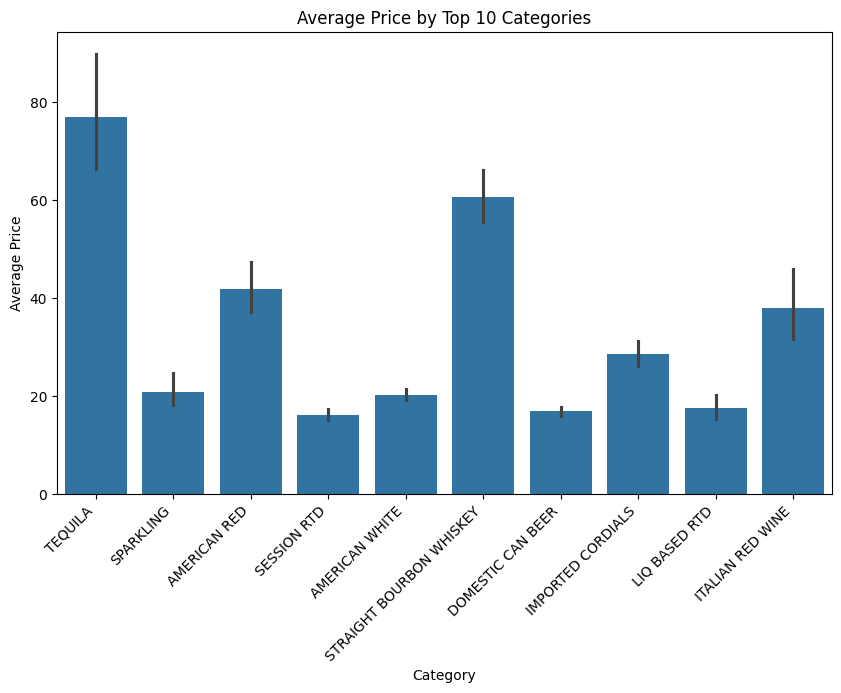

In [17]:
# Visualization 2: Average price by top categories
top_categories = data["Category"].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.barplot(
    data=data[data["Category"].isin(top_categories)],
    x="Category",
    y="Price",
    estimator="mean"
)
plt.xticks(rotation=45, ha="right")
plt.title("Average Price by Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.show()

The bar chart compares the average prices of the top 10 alcohols sold in the dataset. The bar chart shows the relationship between the alcohol type and what determines its price. This visualization is good for predictive modeling because we can predict future prices based on the type of beverage.

## 4. Decision Tree Analysis

In [20]:
# Target variable
y = data["Price"]

# Features
X = data[["Category", "Size", "Total Inventory", "Sale Price", "On Sale", "Discount Amount", "Discount Percent"]]

categorical_features = ["Category", "Size"]
numeric_features = ["Total Inventory", "Sale Price", "On Sale", "Discount Amount", "Discount Percent"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5681, 7), (1421, 7))

The target variable in this project was the beverage Price. We use the other variables like category, size, sale price, on sale, discount amount, and discount price.

In [22]:
tree_depth3 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=3, random_state=42))
])

tree_depth3.fit(X_train, y_train)

pred_tree3 = tree_depth3.predict(X_test)

mse_tree3 = mean_squared_error(y_test, pred_tree3)
r2_tree3 = r2_score(y_test, pred_tree3)

print("Decision Tree Depth 3")
print("MSE:", mse_tree3)
print("R²:", r2_tree3)

Decision Tree Depth 3
MSE: 641.2567983912394
R²: 0.8409979515050707


A Decision Tree Regressor with a max. depth of 3 was trained to be able to predict item prices. The model outputted an MSE of 641.26 and an R squared score of 0.84.

In [23]:
# Decision Tree with depth 6
tree_depth6 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=6, random_state=42))
])

tree_depth6.fit(X_train, y_train)

pred_tree6 = tree_depth6.predict(X_test)

mse_tree6 = mean_squared_error(y_test, pred_tree6)
r2_tree6 = r2_score(y_test, pred_tree6)

print("Decision Tree Depth 6")
print("MSE:", mse_tree6)
print("R²:", r2_tree6)

Decision Tree Depth 6
MSE: 36.21543247020954
R²: 0.991020246546564


The Decision Tree Regresso with a tree depth of 6 performed better than the 3 depth model. It shows a MSE of 36.22 and a R squared of 0.99, the deeper tree model made more accurate predictions but also the deeper the depth the more artifical the model becomes increasing the risk of overfitting.

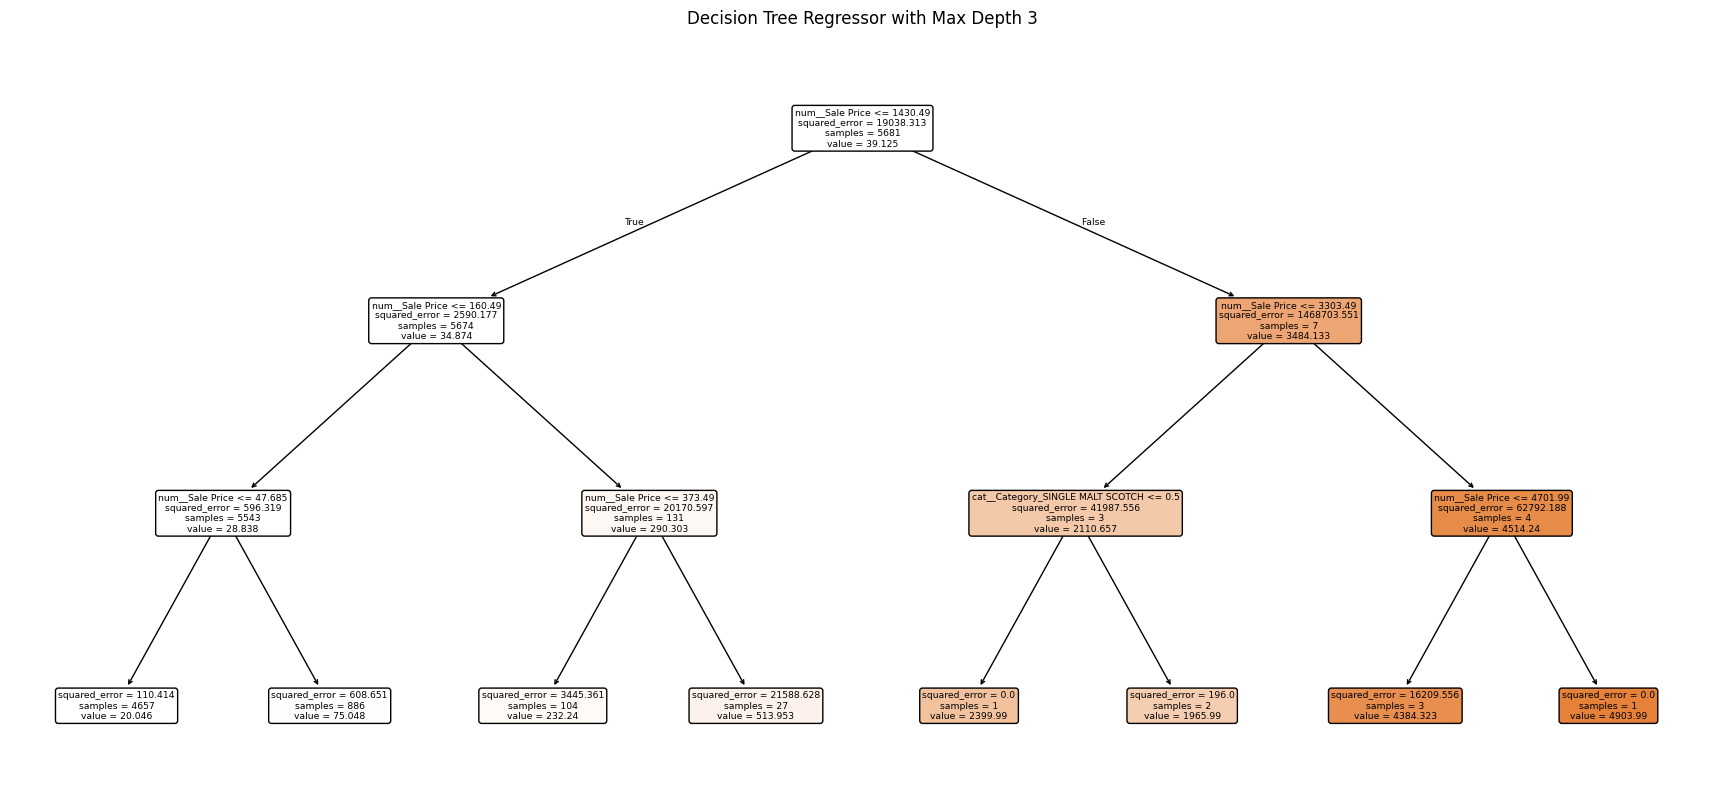

In [24]:
# Get feature names after encoding
feature_names = tree_depth3.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(22,10))
plot_tree(
    tree_depth3.named_steps["model"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree Regressor with Max Depth 3")
plt.show()

The Root Node of the Tree is the Sale Price, making it the most important variable in the first split. The most important condition is that items with higher sales price are predicted to have higher original prices.

One example: If the beverages Sale Price is greater than 1430 - 3303, the model is able to predict a high item price.

The depth 3 tree is easier to understand because it uses less splits and is simpler to interpret. Simpler trees however can be less accurate compared to deeper trees.

## 5. Ensemble Models

In [26]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, pred_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest")
print("MSE:", mse_rf)
print("R²:", r2_rf)

Random Forest
MSE: 44.95457813825451
R²: 0.9888533423253522


MSE of 44.95 and R Squared of 0.989, means this model predicts prices accurately. The Random Forest generalized more accurately because it combined a multitude of trees instead of basing it's decision on one tree.

In [27]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_model.fit(X_train, y_train)

pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, pred_gb)
r2_gb = r2_score(y_test, pred_gb)

print("Gradient Boosting")
print("MSE:", mse_gb)
print("R²:", r2_gb)

Gradient Boosting
MSE: 20.87938682526012
R²: 0.9948228770675599


MSE of 20.88 and a R Squared score of 0.99, shows this modely is highly accurate. Gradient Boosting improved the tree models by building them step by step and mitigating any mistakes made in previous tree models.

## 6. Model Evaluation

The MSE indicator measures prediciton error, so lower MSE values are better. R squares values measures how much variation there is explained by the model, higher values are better.

The tables showed the Gradient Boosting had the best model performance overall with a lower MSE and higher R-squared score. Decision Tree Depth 6 and Random Forest models also preformed well, Decision Tree Depth 3 had the weakest performance.

The ensemble methods did a better job at being more accurate and generalized better than the simple decision trees.

In [28]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree Depth 3",
        "Decision Tree Depth 6",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MSE": [
        mse_tree3,
        mse_tree6,
        mse_rf,
        mse_gb
    ],
    "R2": [
        r2_tree3,
        r2_tree6,
        r2_rf,
        r2_gb
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,MSE,R2
3,Gradient Boosting,20.879387,0.994823
1,Decision Tree Depth 6,36.215432,0.991020
2,Random Forest,44.954578,0.988853
0,Decision Tree Depth 3,641.256798,0.840998


In [29]:
rf_importances = rf_model.named_steps["model"].feature_importances_
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
162,num__Sale Price,0.989330
17,cat__Category_COGNAC,0.003729
84,cat__Category_SINGLE MALT SCOTCH,0.002108
93,cat__Category_TEQUILA,0.001925
154,cat__Size_750ML,0.001481
152,cat__Size_700ML,0.001105
2,cat__Category_AMERICAN RED,0.000150
103,cat__Size_1.5L,0.000042
164,num__Discount Amount,0.000030
56,cat__Category_IRISH WHISKEY,0.000028


## 7. Feature Importance

The most important features in the ensemble models was the num_Sales Price, cat_Category_COGNAC, and cat_Category_SINGLE MALT SCOTCH. These were the strongest variables for the prediciton models to determine future pricings and discounts, sales price was overall had the highest feature importance. Causation is not correlation however in the model.

## 8. Final Reflection

The Gradient Boosting Model showed to perform the best because it had the lowest MSE and highest R-squared score compared to the other models.

The easiest model to explain was the Decision Tree because it had an EDA that could be visualized. Gradient Boosting objectively is the best model due to its predictive accuracy, The Decision Tree offered a more readible and simple approach that allows for consumers or businesses to determine what factors play into their future decisions.